# RNNs en PyTorch — recurso de la Clase 19

**Módulo 07 — Fundamentos de Deep Learning.** El mismo problema de la Clase 18 —sentimiento de reseñas de IMDb— ahora en PyTorch.

Es el par del notebook [`OD_RN2_ESP_M04_S18`](<OD_RN2_ESP_M04_S18_RNNs en TensorFlow - Recurso descargable.ipynb>), y conviene leerlos juntos. Pero **no son equivalentes**: además de las diferencias de framework, cambian los hiperparámetros, y uno en particular explica casi toda la brecha de resultados.

> **Kernel:** `Python 3.12 (dl-env)`.

## Las diferencias con la versión de TensorFlow

| | TensorFlow (Clase 18) | PyTorch (acá) |
|---|---|---|
| Vocabulario | 10.000 palabras | 15.000 |
| **Largo de secuencia** | **1.000 tokens** | **50** |
| Embedding | 128 dimensiones | 100 |
| LSTM | 1 capa de 128 | **2 capas** de 128 |
| Dropout | 0,5 | 0,3 |
| Lote | 64 | 16 |
| Salida | `Dense(1, sigmoid)` | `Linear(1)` sin activación |
| Pérdida | `binary_crossentropy` | `BCEWithLogitsLoss` |
| **Exactitud en test** | **86,64%** | **74,65%** |

**El `max_len` es la diferencia que pesa.** Truncar a 50 tokens contra 1.000 no es un ajuste menor: con *pre-padding*, quedarse con 50 significa conservar solo **las últimas 50 palabras** de cada reseña y tirar el resto. Doce puntos de exactitud salen mayormente de ahí, no del framework.

# IMDb

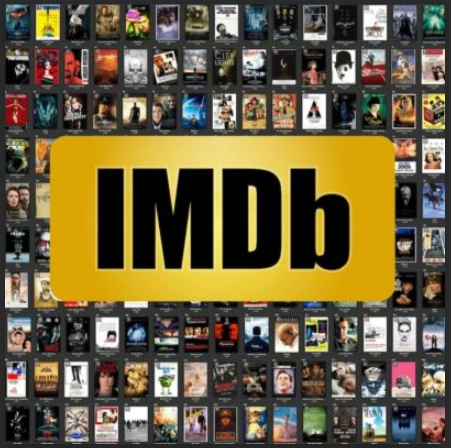

El dataset IMDb (Internet Movie Database) es una base de datos que contiene información sobre películas, series de televisión y otros productos audiovisuales. Existen diferentes versiones de este dataset, pero la más comúnmente utilizada en el contexto de aprendizaje automático es la versión que contiene reseñas de películas y su clasificación en términos de sentimientos (positivos o negativos).

* Reseñas: Textos de reseñas de películas escritas por usuarios. Cada reseña puede ser larga o corta, dependiendo del estilo de escritura del usuario.
* Etiquetas: Cada reseña está etiquetada como positiva o negativa. Estas etiquetas se utilizan para entrenar modelos de clasificación que pueden predecir el sentimiento de una reseña nueva.

El dataset IMDb para análisis de sentimientos es bastante grande. La versión más común del dataset tiene la siguiente distribución:
* 50,000 reseñas para el conjunto de entrenamiento (25.000 reseñas positivas y 25.000 reseñas negativas)
* 50,000 reseñas para el conjunto de prueba (25.000 reseñas positivas y 25.000 reseñas negativas)

## 1. Librerías

Notar que **PyTorch usa el dataset de Keras**: `from keras.datasets import imdb`. No es un error — PyTorch no trae IMDb tokenizado de fábrica, y aprovechar el de Keras evita tener que descargar y tokenizar el corpus a mano. Es habitual mezclar así las bibliotecas.

`sequence.pad_sequences` viene del mismo lado, por la misma razón.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from keras.datasets import imdb
from keras.preprocessing import sequence

## 2. Cargar los datos

- **`vocab_size = 15000`** — 5.000 palabras más que la versión de TensorFlow. Vocabulario más grande significa cubrir más palabras poco frecuentes, a costa de más parámetros en la capa `Embedding`.
- **`max_len = 50`** — el recorte agresivo. Cada reseña queda en 50 tokens.

Para dimensionar: una reseña típica de IMDb ronda las 230 palabras, y muchas superan las 500. Con `max_len=50` se descarta la mayor parte del texto de casi todas.

In [ ]:
vocab_size = 15000
max_len = 50

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

## 3. Emparejar el largo

`pad_sequences` con el default de *pre-padding*: rellena con ceros adelante y trunca por adelante.

**Truncar por adelante conserva el final de la reseña.** Es una decisión razonable en análisis de sentimiento, porque las conclusiones suelen estar al final ("...en resumen, una pérdida de tiempo"). Pero con solo 50 tokens se pierde todo el desarrollo.

In [ ]:
x_train = sequence.pad_sequences(x_train, maxlen=max_len)
x_test = sequence.pad_sequences(x_test, maxlen=max_len)

## 4. A tensores

Dos tipos distintos, y cada uno tiene su motivo:

- **`x` en `long`** — son índices de palabra, y la capa `Embedding` los usa para buscar filas en su tabla. Necesita enteros.
- **`y` en `float`** — porque la pérdida elegida es `BCEWithLogitsLoss`, que compara contra un valor continuo entre 0 y 1.

Es una diferencia con los notebooks de clasificación anteriores, donde las etiquetas iban en `long` para `CrossEntropyLoss`. Con pérdidas binarias, `float`.

In [ ]:
x_train = torch.tensor(x_train, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.float)

x_test = torch.tensor(x_test, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.float)

## 5. `DataLoader`

Lotes de 16, con `shuffle=True` en train y `False` en test. Con 25.000 reseñas dan 1.563 lotes por época — muchos más que los 391 de la versión de TensorFlow, que usa lotes de 64.

Lotes más chicos significan más actualizaciones de pesos por época, pero también más tiempo de cómputo por el overhead de cada paso.

In [ ]:
batch_size = 16
train_data = torch.utils.data.TensorDataset(x_train, y_train)
test_data = torch.utils.data.TensorDataset(x_test, y_test)

train_loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size = batch_size)
test_loader = torch.utils.data.DataLoader(test_data, shuffle=False, batch_size = batch_size)

## 6. El modelo

La estructura es la misma que en Keras, escrita como clase.

| Capa | Qué hace |
|---|---|
| `nn.Embedding(vocab_size, embedding_dim)` | tabla de 15.000 × 100 que convierte cada ID en un vector |
| `nn.LSTM(..., num_layers=2, batch_first=True, dropout=0.3)` | **dos capas** apiladas de LSTM |
| `nn.Linear(hidden_dim, output_dim)` | de 128 a 1: la salida |
| `nn.Dropout(dropout)` | aplicado a la entrada del LSTM y a su salida |

**Tres detalles del `forward` que vale entender:**

**`batch_first=True`** cambia el orden esperado de las dimensiones a `(lote, tiempo, features)`. Sin esto, PyTorch espera `(tiempo, lote, features)`, que es el default histórico y una fuente clásica de errores de forma.

**`lstm_out, (hidden, cell) = self.lstm(embedded)`** — la LSTM devuelve tres cosas: la salida de **todos** los pasos (`lstm_out`), el **estado oculto** final y el **estado de celda** final. Que devuelva `hidden` y `cell` por separado es la marca de LSTM: son los dos estados de los que hablaba la Clase 17. Una GRU devolvería solo `hidden`.

**`hidden[-1,:,:]`** toma el estado oculto de la **última capa** —el índice `-1` recorre la dimensión de capas, no la de tiempo—. Como el modelo tiene 2 capas apiladas, `hidden` tiene forma `(2, lote, 128)` y esto se queda con la de arriba. Es el equivalente al `return_sequences=False` de Keras.

**La salida no lleva sigmoide**, y es correcto: la pérdida de la celda siguiente la aplica internamente. Es el mismo patrón que `CrossEntropyLoss` con las capas densas de los notebooks anteriores.

In [ ]:
class LSTMModel(nn.Module):

    def __init__ (self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout):
        super(LSTMModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=n_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.dropout(self.embedding(text))

        lstm_out, (hidden, cell) = self.lstm(embedded)

        hidden = self.dropout(hidden[-1,:,:])

        output = self.fc(hidden)
        return output

## 7. Hiperparámetros

`n_layers=2` apila dos LSTM: la segunda recibe como entrada la salida paso a paso de la primera. Más capas permiten representar patrones más abstractos, a costa de más parámetros y más tiempo.

> **Detalle de PyTorch:** el argumento `dropout` de `nn.LSTM` se aplica **entre capas**, no dentro de cada una, y por eso **solo tiene efecto si `num_layers > 1`**. Con una sola capa PyTorch emite una advertencia y lo ignora. Acá, con 2 capas, sí actúa.

In [ ]:
embedding_dim = 100
hidden_dim = 128
output_dim = 1
n_layers = 2
dropout = 0.3

model = LSTMModel(vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout)

## 8. Pérdida y optimizador

**`BCEWithLogitsLoss`** es la pérdida binaria que **incluye la sigmoide**. Por eso el modelo termina en un `Linear` sin activación.

La alternativa sería `BCELoss` con una sigmoide explícita en el modelo, pero la versión combinada es **numéricamente más estable**: evita calcular el logaritmo de valores muy cercanos a cero, que es donde aparecen los `NaN`. Es la recomendación oficial de PyTorch.

Es exactamente el mismo razonamiento por el que `CrossEntropyLoss` incluye el `log_softmax`.

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 9. La función de exactitud

Como PyTorch no trae métricas, hay que escribirlas.

`torch.sigmoid(preds)` convierte los logits en probabilidades —acá sí, explícitamente, porque para *medir* hace falta la probabilidad— y `torch.round` las lleva a 0 o 1 con umbral 0,5.

En Keras esto es `metrics=['accuracy']` y nada más.

In [ ]:
def binary_accuracy(preds, y):
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()

    acc = correct.sum() / len(correct)
    return acc

## 10. El bucle de entrenamiento

El mismo esquema de cinco pasos de siempre, encapsulado en una función.

**`predictions = model(text).squeeze(1)`** — el modelo devuelve forma `(lote, 1)` y las etiquetas son `(lote,)`. Sin el `squeeze`, el *broadcasting* de PyTorch las expandiría a `(lote, lote)` y la pérdida se calcularía **mal sin dar error**. Es otra falla silenciosa de las que conviene tener presentes.

El `print` va al final de cada época, así que debería imprimir una línea por época.

In [ ]:
def train(model, iterador, optimizer, criterion, n_epochs):
    model.train()

    for epoch in range(n_epochs):
        epoch_loss = 0
        epoch_acc = 0

        for batch in iterador:
            optimizer.zero_grad()
            text, labels = batch

            predictions = model(text).squeeze(1)

            loss = criterion(predictions, labels)
            acc = binary_accuracy(predictions, labels)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_acc += acc.item()

        print(f"Epoch: {epoch} - Loss: {epoch_loss / len(iterador):.2f} - Accuracy: {(epoch_acc / len(iterador))*100:.2f}%")

### El output no corresponde al código

La llamada pide **20 épocas** (`train(..., 20)`) pero el output guardado tiene **una sola línea**:

```
Epoch: 0 - Loss: 0.60 - Accuracy: 66.32%
```

Con 20 épocas habría 20 líneas. El output es de una corrida con `n_epochs=1`; después se editó el código a 20 y no se volvió a ejecutar.

Es el mismo desfase entre código y resultado que apareció en los recursos del módulo 06 y en el de la Clase 5. Si se ejecuta el notebook tal como está, el entrenamiento va a tardar **veinte veces más** que lo que sugiere el output y va a dar un resultado bastante mejor que el 74,65% que figura abajo.

In [ ]:
train(model, train_loader, optimizer, criterion, 20)

Epoch: 0 - Loss: 0.60 - Accuracy: 66.32%


## 11. La función de evaluación

`model.eval()` y `torch.no_grad()`, como corresponde. Devuelve pérdida y exactitud promediadas sobre los lotes.

Notar que **no se evalúa durante el entrenamiento**: la función `train` no mira el test en ningún momento. Es más prolijo que el `validation_data` de la versión de Keras, aunque impide ver la curva de validación época a época.

In [ ]:
def evaluate(model, iterator, criterion):
    epoch_loss = 0
    epoch_acc = 0
    model.eval()

    with torch.no_grad():
        for batch in iterator:
            text, labels = batch

            predictions = model(text).squeeze(1)

            loss = criterion(predictions, labels)
            acc = binary_accuracy(predictions, labels)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

## 12. El resultado

**Test accuracy: 74,65%**, contra el **86,64%** de la versión en TensorFlow.

**Los doce puntos de diferencia no son del framework.** El factor que más pesa es `max_len`: 50 tokens contra 1.000. Con 50 se conservan solo las últimas 50 palabras de cada reseña, y buena parte de la información se descarta antes de que la red la vea.

Y hay que recordar el punto anterior: **este 74,65% corresponde a una corrida de una sola época**, no de las 20 que pide el código. Con 20 épocas el resultado sería mejor.

Para comparar frameworks en serio habría que igualar `max_len`, el vocabulario, la arquitectura y la cantidad de épocas. Así como están, los dos notebooks muestran **el mismo problema resuelto con dos herramientas**, no una competencia entre ellas.

In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f'Test loss:  {test_loss:.2f} - Test Acc: {test_acc * 100:.2f}%')

Test loss:  0.50 - Test Acc: 74.65%


---

## Resumen

### Las piezas de PyTorch para texto

| Pieza | Detalle que importa |
|---|---|
| `nn.Embedding` | recibe **enteros** (`long`): son índices para buscar en su tabla |
| `nn.LSTM` | devuelve `(salida_de_todos_los_pasos, (hidden, cell))` — los **dos estados** son la marca de LSTM |
| `batch_first=True` | cambia el orden a `(lote, tiempo, features)`; sin esto el default es `(tiempo, lote, features)` |
| `hidden[-1,:,:]` | el estado de la **última capa apilada**, equivalente a `return_sequences=False` |
| `BCEWithLogitsLoss` | incluye la sigmoide; por eso el modelo termina en `Linear` sin activación |
| `dropout` en `nn.LSTM` | actúa **entre capas**: no hace nada si `num_layers=1` |

### Comparación con la versión de Keras

| | TensorFlow | PyTorch |
|---|---|---|
| Líneas de modelo | 5 | ~20 (clase completa) |
| Métricas | `metrics=['accuracy']` | función escrita a mano |
| Entrenamiento | `model.fit()` | bucle en una función |
| Validación por época | `validation_data` | no hay |
| **`max_len`** | **1.000** | **50** |
| **Exactitud** | **86,64%** | **74,65%** |

### Lo que hay que saber leer de este notebook

1. **La diferencia de exactitud es de hiperparámetros, no de framework.** `max_len=50` contra 1.000 descarta la mayor parte de cada reseña.
2. **El output no corresponde al código:** dice 20 épocas y muestra una sola. El 74,65% es de una época.
3. **`squeeze(1)` no es opcional.** Sin él, el *broadcasting* calcula la pérdida mal y **no da error**.

### Dos fallas silenciosas, una en cada notebook

Los dos recursos de esta clase tienen un problema que **no lanza excepción**:

- **En TensorFlow**: el `Tokenizer` nuevo genera IDs que no corresponden al vocabulario del modelo, y las predicciones salen invertidas con formato impecable.
- **En PyTorch**: el output guardado es de una corrida distinta de la que describe el código.

Es el patrón que más se repite en los recursos del curso, y la lección práctica es siempre la misma: **que el código corra y produzca números con buen formato no significa que los números signifiquen algo.**